initial state X TEE1～TEE6

ブートストラップで誤差

/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)


Best over grid: pc≈0.859625, zeta≈2.7292, S≈10.57 (nu fixed=1.333)


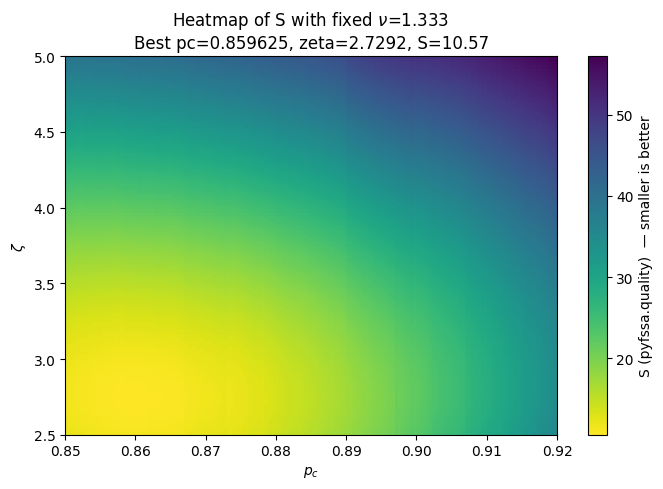

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力と基本設定
# ======================
npz_path = "TEE_merged.npz"   # あなたの npz
# L はあなたの流儀に合わせて用意（TEE_cols と同数・同順）
# 例: Ah=36,54,72,90,108 → L=sqrt(Ah)
L_list   = [np.sqrt(18),np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_cols = [1, 2, 3, 4, 5, 6]  # 使う系列（TEE2..TEE6）

# p 窓（あなたのスクリプトに合わせる）
pc_min = 0.72
pc_max = 0.89

# --- ここを "固定ν" にする ---
NU_FIXED = 1.333  # 例: 1.80（必要なら 1.7656 などに変更）

# 探索レンジ（必要に応じて広げる）
PC_RANGE   = (0.85, 0.92)   # pc の探索範囲
ZETA_RANGE = (2.5,  5.0)    # zeta の探索範囲
N_PC, N_ZETA = 161, 121     # グリッド解像度

# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（variance と SE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

def key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{key(c)}_var"]     for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{key(c)}_var_err"] for c in TEE_cols], float)

# --- p 窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# (pc, zeta) グリッドで S=quality を評価
# ======================
pc_vals   = np.linspace(*PC_RANGE,   N_PC)
zeta_vals = np.linspace(*ZETA_RANGE, N_ZETA)
S_grid = np.empty((N_ZETA, N_PC), float); S_grid[:] = np.nan

best = (np.inf, None, None)

for iz, zeta in enumerate(zeta_vals):
    for jp, pc in enumerate(pc_vals):
        # pyfssa のスケール変換（νは固定 → pc と ζ を走査）
        try:
            xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                         pc, NU_FIXED, zeta)
            S = fssa.quality(xs, ys, dys)  # ← pyfssaベースの評価関数
        except Exception:
            S = np.inf
        S_grid[iz, jp] = S
        if np.isfinite(S) and S < best[0]:
            best = (S, pc, zeta)

Smin, pc_best, zeta_best = best
print(f"Best over grid: pc≈{pc_best:.6f}, zeta≈{zeta_best:.4f}, S≈{Smin:.4g} (nu fixed={NU_FIXED})")

# ======================
# 可視化
# ======================
plt.figure(figsize=(7,5))
extent = [pc_vals[0], pc_vals[-1], zeta_vals[0], zeta_vals[-1]]
im = plt.imshow(S_grid, extent=extent, origin='lower', aspect='auto', cmap="viridis_r")
plt.colorbar(im, label="S (pyfssa.quality)  — smaller is better")
plt.xlabel(r"$p_c$"); plt.ylabel(r"$\zeta$")
plt.title(f"Heatmap of S with fixed $\\nu$={NU_FIXED}\nBest pc={pc_best:.6f}, zeta={zeta_best:.4f}, S={Smin:.4g}")
plt.tight_layout()
plt.savefig("S_heatmap_pyfssa_fixed_nu1333.png", dpi=300)
plt.show()

# 保存（再利用用）
np.savez("Sgrid_pyfssa_fixednu.npz",
         pc_vals=pc_vals, zeta_vals=zeta_vals, S_grid=S_grid,
         nu_fixed=NU_FIXED, pc_range=PC_RANGE, zeta_range=ZETA_RANGE,
         pg_window=(pc_min, pc_max),
         L_list=np.array(L_list), TEE_cols=np.array(TEE_cols))


Best over grid: pc≈0.877125, zeta≈3.8333, S≈4.948 (nu fixed=1.7656)


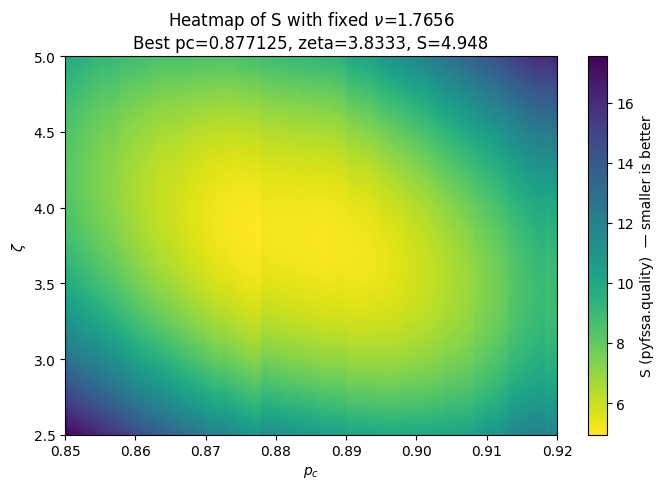

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力と基本設定
# ======================
npz_path = "fss_merged.npz"   # あなたの npz
# L はあなたの流儀に合わせて用意（TEE_cols と同数・同順）
# 例: Ah=36,54,72,90,108 → L=sqrt(Ah)
L_list   = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_cols = [1, 2, 3, 4, 5, 6]  # 使う系列（TEE2..TEE6）

# p 窓（あなたのスクリプトに合わせる）
pc_min = 0.72
pc_max = 0.89

# --- ここを "固定ν" にする ---
NU_FIXED = 1.7656 # 例: 1.80（必要なら 1.7656 などに変更）

# 探索レンジ（必要に応じて広げる）
PC_RANGE   = (0.85, 0.92)   # pc の探索範囲
ZETA_RANGE = (2.5,  5.0)    # zeta の探索範囲
N_PC, N_ZETA = 161, 121     # グリッド解像度

# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（variance と SE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

def key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{key(c)}_var"]     for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{key(c)}_var_err"] for c in TEE_cols], float)

# --- p 窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# (pc, zeta) グリッドで S=quality を評価
# ======================
pc_vals   = np.linspace(*PC_RANGE,   N_PC)
zeta_vals = np.linspace(*ZETA_RANGE, N_ZETA)
S_grid = np.empty((N_ZETA, N_PC), float); S_grid[:] = np.nan

best = (np.inf, None, None)

for iz, zeta in enumerate(zeta_vals):
    for jp, pc in enumerate(pc_vals):
        # pyfssa のスケール変換（νは固定 → pc と ζ を走査）
        try:
            xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                         pc, NU_FIXED, zeta)
            S = fssa.quality(xs, ys, dys)  # ← pyfssaベースの評価関数
        except Exception:
            S = np.inf
        S_grid[iz, jp] = S
        if np.isfinite(S) and S < best[0]:
            best = (S, pc, zeta)

Smin, pc_best, zeta_best = best
print(f"Best over grid: pc≈{pc_best:.6f}, zeta≈{zeta_best:.4f}, S≈{Smin:.4g} (nu fixed={NU_FIXED})")

# ======================
# 可視化
# ======================
plt.figure(figsize=(7,5))
extent = [pc_vals[0], pc_vals[-1], zeta_vals[0], zeta_vals[-1]]
im = plt.imshow(S_grid, extent=extent, origin='lower', aspect='auto', cmap="viridis_r")
plt.colorbar(im, label="S (pyfssa.quality)  — smaller is better")
plt.xlabel(r"$p_c$"); plt.ylabel(r"$\zeta$")
plt.title(f"Heatmap of S with fixed $\\nu$={NU_FIXED}\nBest pc={pc_best:.6f}, zeta={zeta_best:.4f}, S={Smin:.4g}")
plt.tight_layout()
plt.savefig("S_heatmap_pyfssa_fixed_nu17656.png", dpi=300)
plt.show()

# 保存（再利用用）
np.savez("Sgrid_pyfssa_fixednu.npz",
         pc_vals=pc_vals, zeta_vals=zeta_vals, S_grid=S_grid,
         nu_fixed=NU_FIXED, pc_range=PC_RANGE, zeta_range=ZETA_RANGE,
         pg_window=(pc_min, pc_max),
         L_list=np.array(L_list), TEE_cols=np.array(TEE_cols))
